In [ ]:
# Implement the non-parametric Locally Weighted Regression algorithm in order to fit data points. Select appropriate data set for your experiment and draw graphs

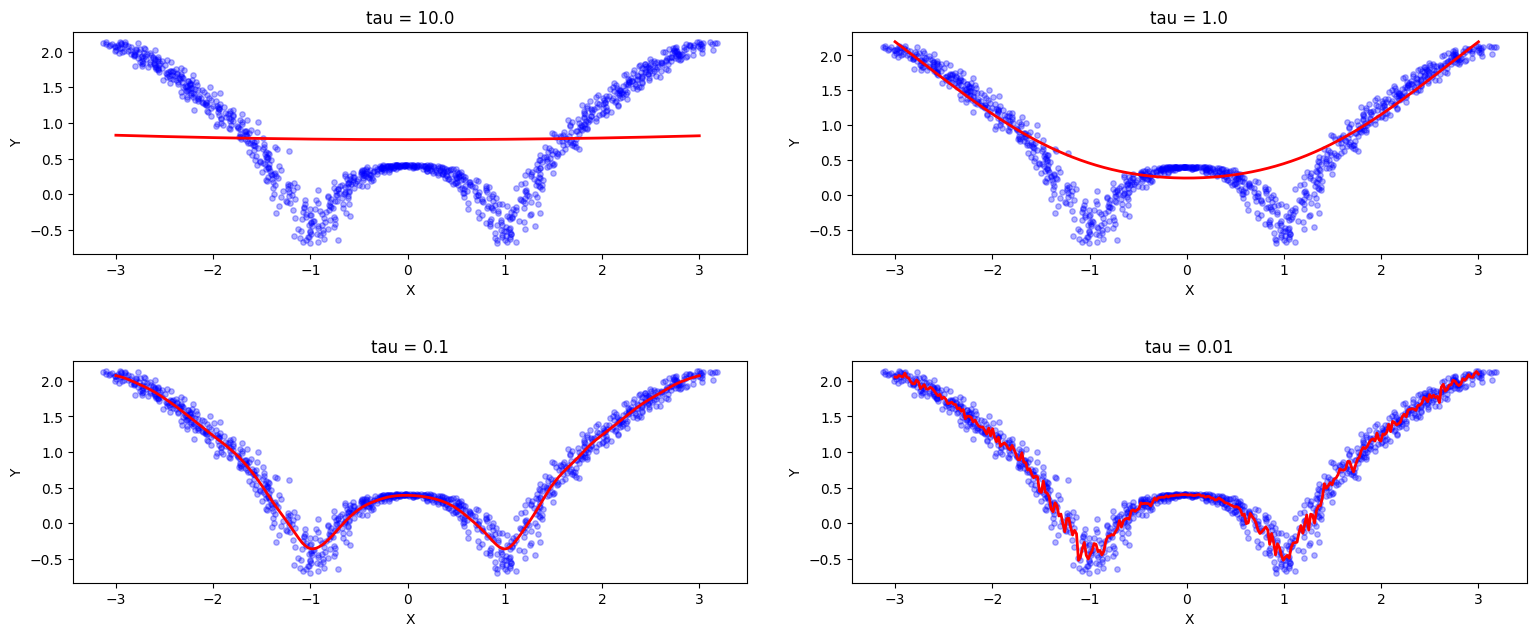

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Radial kernel (Gaussian)
def radial_kernel(x0, X, tau):
    return np.exp(np.sum((X - x0) ** 2, axis=1) / (-2 * tau * tau))

# Local regression
def local_regression(x0, X, Y, tau):
    x0 = np.r_[1, x0]                # Add bias
    X = np.c_[np.ones(len(X)), X]    # Add bias column

    weights = radial_kernel(x0, X, tau)
    xw = X.T * weights

    beta = np.linalg.pinv(xw @ X) @ xw @ Y
    return x0 @ beta


# Generate dataset
n = 1000
X = np.linspace(-3, 3, num=n)
Y = np.log(np.abs(X**2 - 1) + 0.5)

# Add noise (jitter)
X += np.random.normal(scale=0.1, size=n)

# Domain for prediction
domain = np.linspace(-3, 3, num=300)


# Plot function
def plot_lwr(tau, subplot_index):
    plt.subplot(2, 2, subplot_index)
    
    predictions = [local_regression(x0, X, Y, tau) for x0 in domain]
    
    plt.scatter(X, Y, color='blue', alpha=0.3, s=15)
    plt.plot(domain, predictions, color='red', linewidth=2)
    
    plt.title(f"tau = {tau}")
    plt.xlabel("X")
    plt.ylabel("Y")


# Create one figure with all plots
plt.figure(figsize=(16,7))   

plot_lwr(10.0, 1)
plot_lwr(1.0, 2)
plot_lwr(0.1, 3)
plot_lwr(0.01, 4)

plt.tight_layout(pad=3.0)     
plt.show()